<a href="https://colab.research.google.com/github/KAVYADINDI/StudentAcademicPerformancePrediction/blob/main/test_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML/student_data.csv')

# **DataCleaning**

**Remove missing values**

In [106]:
# check for null values, column data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

We have a clean dataset with 0 NaN values.

**Understanding Distributions**

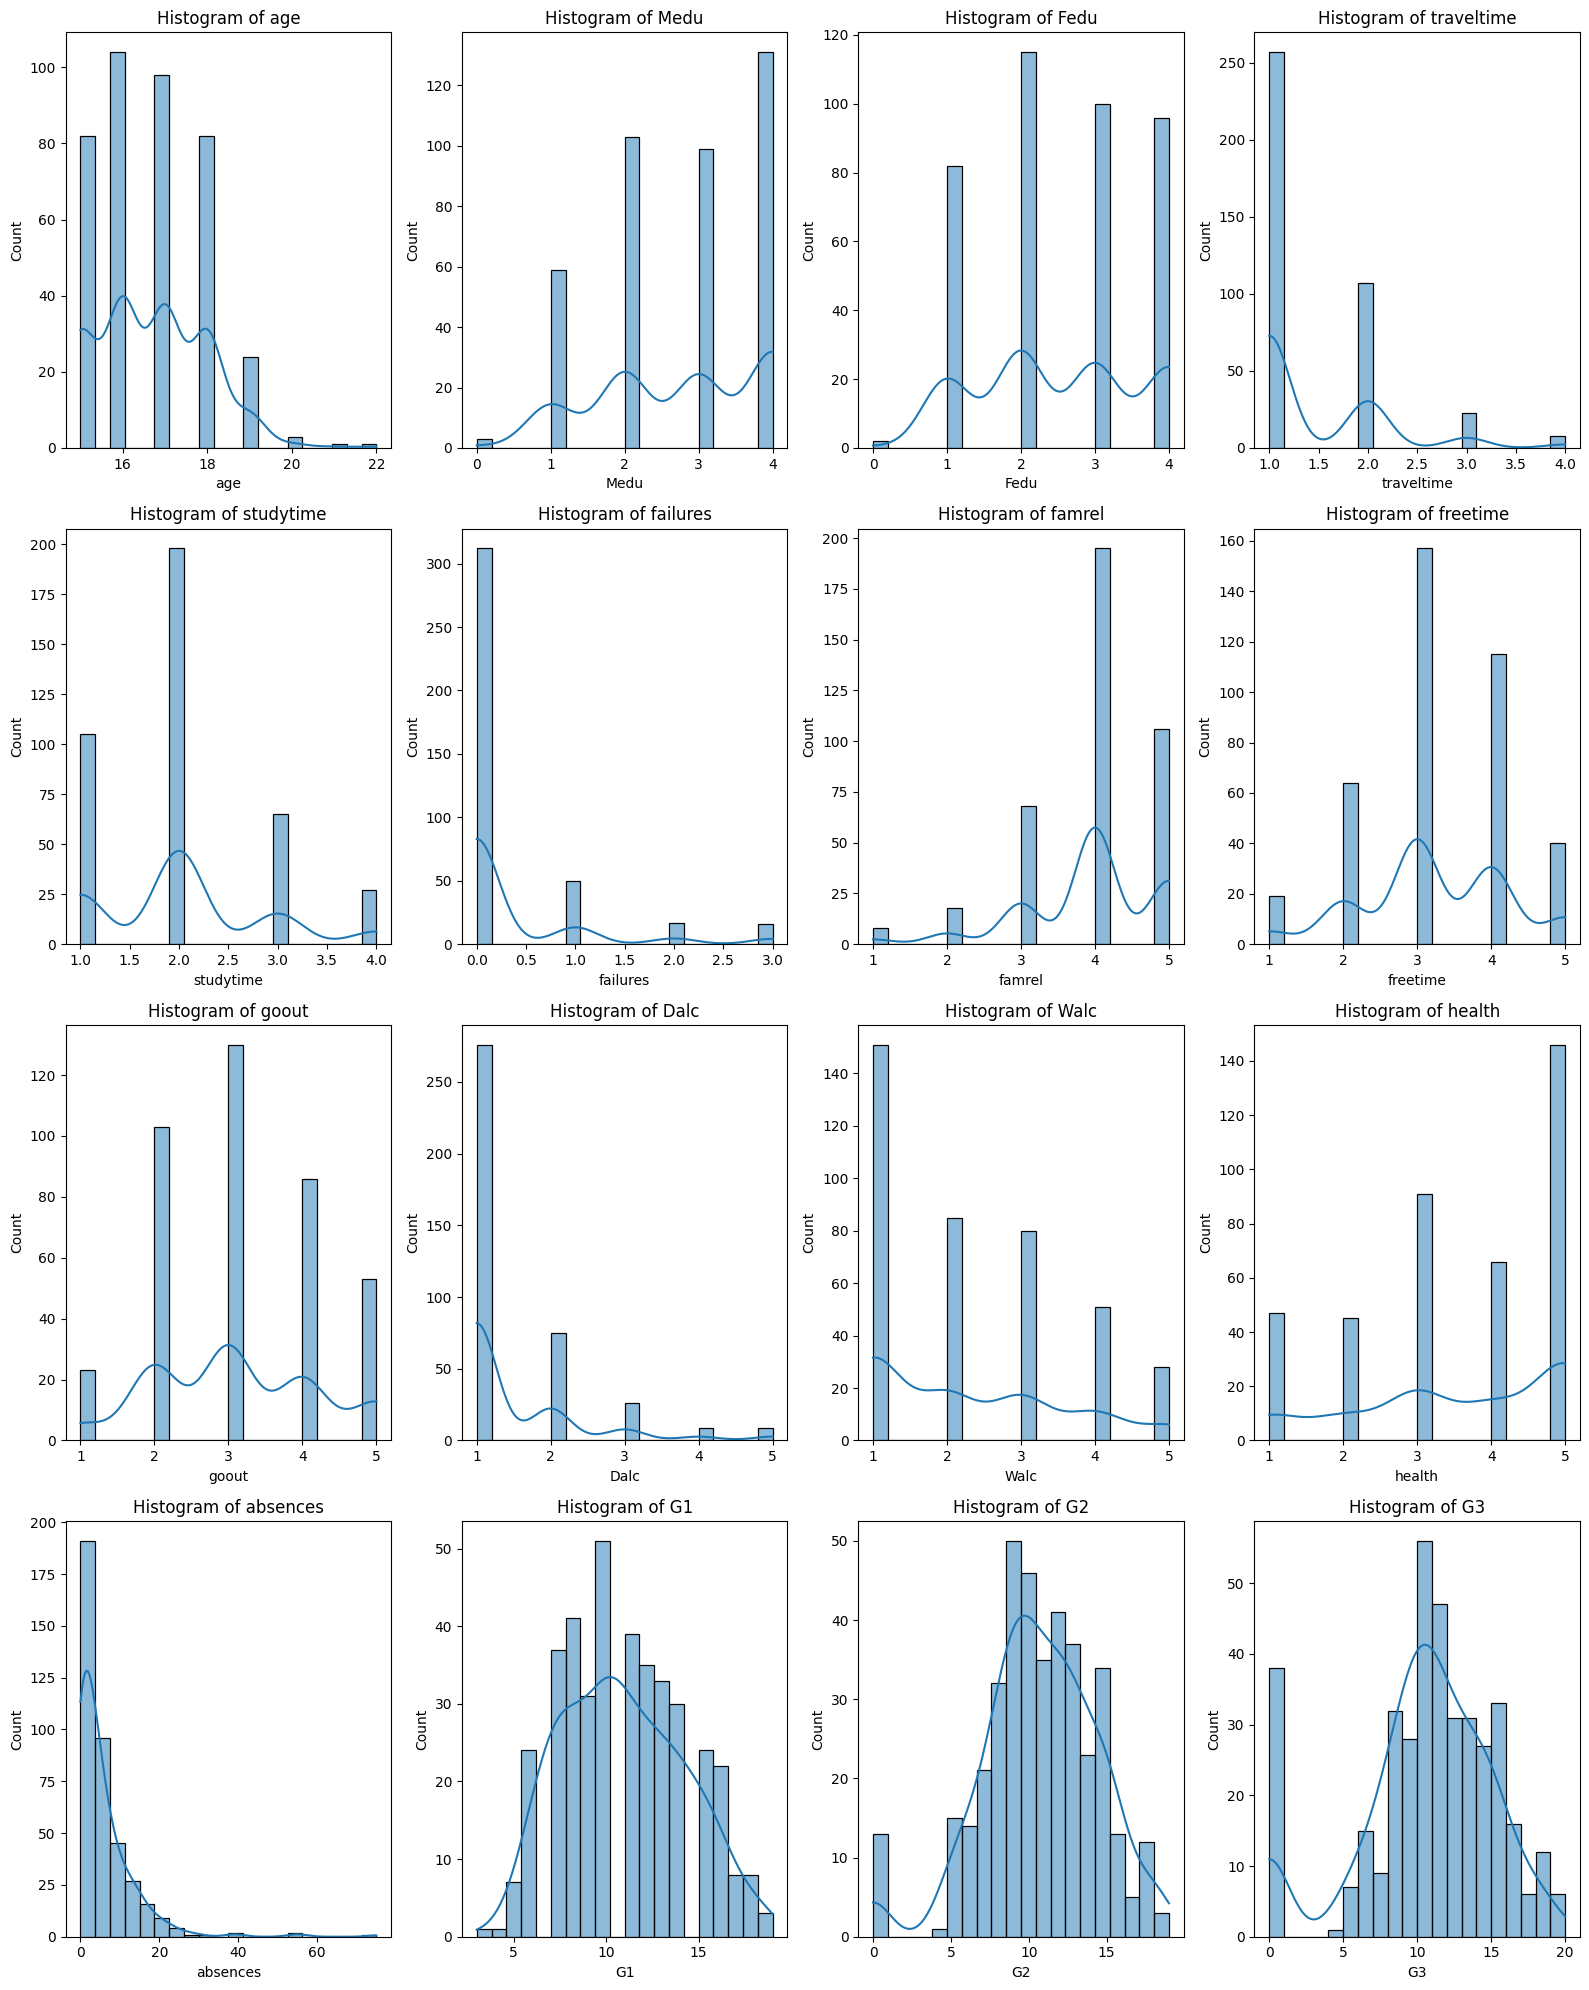

In [107]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(16, 20))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 4, i) # Changed from 5, 3 to 4, 4 to accommodate 16 columns
    sns.histplot(df[col], kde=True, bins=20)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

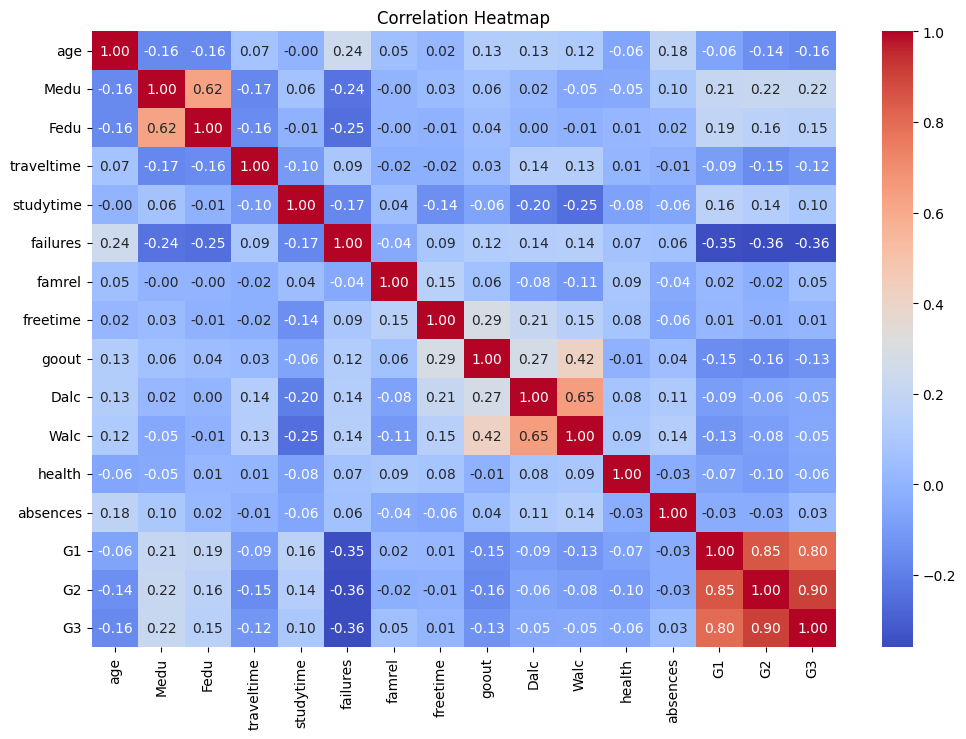

In [108]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Outliers Detection**

In [109]:

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
            (df[numeric_cols] > (Q3 + 1.5 * IQR)))

outliers.sum()

,0
age,1
Medu,0
Fedu,2
traveltime,8
studytime,27
failures,83
famrel,26
freetime,19
goout,0
Dalc,18


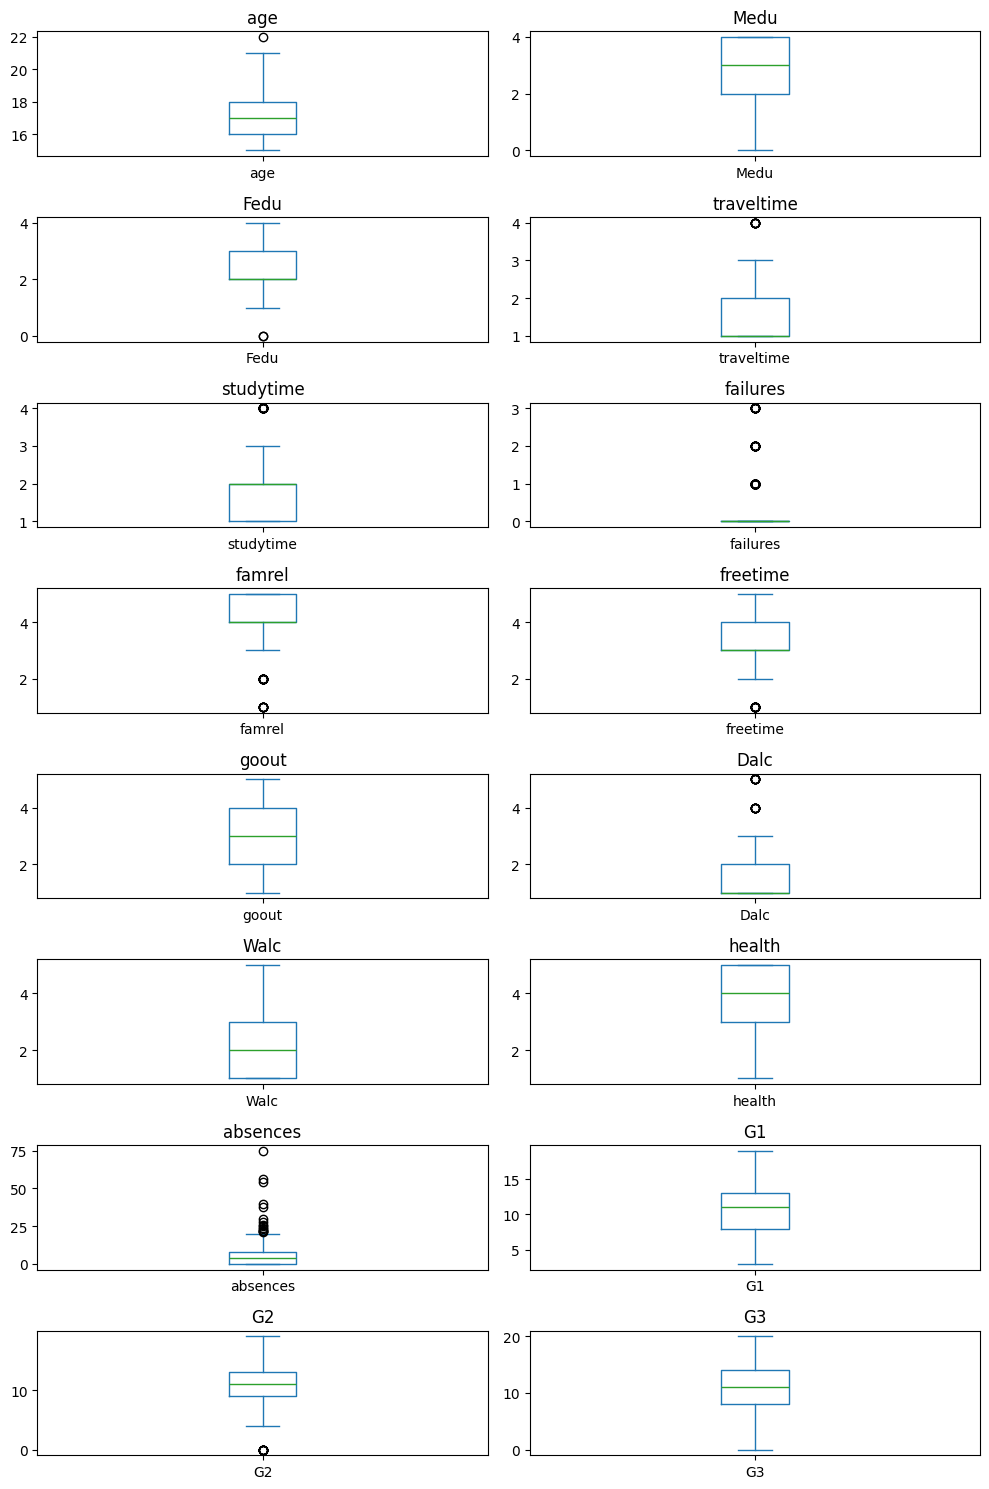

In [110]:
fig, axes = plt.subplots(nrows=8, ncols=2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].plot(kind='box', ax=axes[i], title=col)

plt.tight_layout()
plt.show()

Outliers in this dataset represent real student behavior (e.g., high absences, low grades), not data errors.
Tree-based models handle them well, and scaling stabilizes KNN,
so removing or capping outliers would lose important predictive information.

# **PreProcessing:**

**Label Encoding:**

schoolsup,
famsup,
paid,
activities,
nursery,
higher,
internet,
romantic: (yes → 1, no → 0)

sex: (F → 0, M → 1)

address: (R → 0, U → 1)

famsize: (LT3 → 0, GT3 → 1)

Pstatus: (A → 0, T → 1)

In [111]:
sex_counts = df['sex'].value_counts()
print(sex_counts)

sex
F    208
M    187
Name: count, dtype: int64


In [112]:
# Define the mapping for 'sex' column
sex_mapping = {'F': 0, 'M': 1}

# Apply the mapping and convert to int64
df['sex'] = df['sex'].map(sex_mapping).astype('int64')

# Verify the changes
print(df['sex'].value_counts())
print(df['sex'].dtype)


sex
0    208
1    187
Name: count, dtype: int64
int64


In [113]:
address_counts = df['address'].value_counts()
print(address_counts)

address
U    307
R     88
Name: count, dtype: int64


In [114]:
# Define the mapping for 'address' column
address_mapping = {'R': 0, 'U': 1}

# Apply the mapping and convert to int64
df['address'] = df['address'].map(address_mapping).astype('int64')

# Verify the changes
print(df['address'].value_counts())
print(df['address'].dtype)

address
1    307
0     88
Name: count, dtype: int64
int64


In [115]:
famsize_counts = df['famsize'].value_counts()
print(famsize_counts)

famsize
GT3    281
LE3    114
Name: count, dtype: int64


In [120]:
# Define the mapping for 'famsize' column
famsize_mapping = {'GT3': 1, 'LE3': 0}

# Apply the mapping and convert to int64
df['famsize'] = df['famsize'].map(famsize_mapping).astype('int64')

# Verify the changes
print(df['famsize'].value_counts())
print(df['famsize'].dtype)

famsize
1    281
0    114
Name: count, dtype: int64
int64


In [116]:
# Check current counts for 'Pstatus'
Pstatus_counts = df['Pstatus'].value_counts()
print(Pstatus_counts)

Pstatus
T    354
A     41
Name: count, dtype: int64


In [117]:
# Define the mapping for 'Pstatus' column (assuming 'T' for Together, 'A' for Apart)
Pstatus_mapping = {'T': 1, 'A': 0}

# Apply the mapping and then convert to int64
df['Pstatus'] = df['Pstatus'].map(Pstatus_mapping).astype('int64')

# Verify the changes
print(df['Pstatus'].value_counts())
print(df['Pstatus'].dtype)

Pstatus
1    354
0     41
Name: count, dtype: int64
int64


In [118]:
# Check current counts for 'schoolsup'
schoolsup_counts = df['schoolsup'].value_counts()
print(schoolsup_counts)

schoolsup
no     344
yes     51
Name: count, dtype: int64


In [119]:
# Define the mapping for 'schoolsup' column
schoolsup_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['schoolsup'] = df['schoolsup'].map(schoolsup_mapping).astype('int64')

# Verify the changes
print(df['schoolsup'].value_counts())
print(df['schoolsup'].dtype)

schoolsup
0    344
1     51
Name: count, dtype: int64
int64


In [121]:
# Check current counts for 'famsup'
famsup_counts = df['famsup'].value_counts()
print(famsup_counts)

famsup
yes    242
no     153
Name: count, dtype: int64


In [122]:
# Define the mapping for 'famsup' column
famsup_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['famsup'] = df['famsup'].map(famsup_mapping).astype('int64')

# Verify the changes
print(df['famsup'].value_counts())
print(df['famsup'].dtype)

famsup
1    242
0    153
Name: count, dtype: int64
int64


In [123]:
# Check current counts for 'paid'
paid_counts = df['paid'].value_counts()
print(paid_counts)

paid
no     214
yes    181
Name: count, dtype: int64


In [124]:
# Define the mapping for 'paid' column
paid_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['paid'] = df['paid'].map(paid_mapping).astype('int64')

# Verify the changes
print(df['paid'].value_counts())
print(df['paid'].dtype)

paid
0    214
1    181
Name: count, dtype: int64
int64


In [125]:
# Check current counts for 'activities'
activities_counts = df['activities'].value_counts()
print(activities_counts)

activities
yes    201
no     194
Name: count, dtype: int64


In [126]:
# Define the mapping for 'activities' column
activities_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['activities'] = df['activities'].map(activities_mapping).astype('int64')

# Verify the changes
print(df['activities'].value_counts())
print(df['activities'].dtype)

activities
1    201
0    194
Name: count, dtype: int64
int64


In [127]:
# Check current counts for 'nursery'
nursery_counts = df['nursery'].value_counts()
print(nursery_counts)

nursery
yes    314
no      81
Name: count, dtype: int64


In [128]:
# Define the mapping for 'nursery' column
nursery_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['nursery'] = df['nursery'].map(nursery_mapping).astype('int64')

# Verify the changes
print(df['nursery'].value_counts())
print(df['nursery'].dtype)

nursery
1    314
0     81
Name: count, dtype: int64
int64


In [129]:
# Check current counts for 'higher'
higher_counts = df['higher'].value_counts()
print(higher_counts)

higher
yes    375
no      20
Name: count, dtype: int64


In [130]:
# Define the mapping for 'higher' column
higher_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['higher'] = df['higher'].map(higher_mapping).astype('int64')

# Verify the changes
print(df['higher'].value_counts())
print(df['higher'].dtype)

higher
1    375
0     20
Name: count, dtype: int64
int64


In [131]:
# Check current counts for 'internet'
internet_counts = df['internet'].value_counts()
print(internet_counts)

internet
yes    329
no      66
Name: count, dtype: int64


In [132]:
# Define the mapping for 'internet' column
internet_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['internet'] = df['internet'].map(internet_mapping).astype('int64')

# Verify the changes
print(df['internet'].value_counts())
print(df['internet'].dtype)

internet
1    329
0     66
Name: count, dtype: int64
int64


In [133]:
# Check current counts for 'romantic'
romantic_counts = df['romantic'].value_counts()
print(romantic_counts)

romantic
no     263
yes    132
Name: count, dtype: int64


In [134]:
# Define the mapping for 'romantic' column
romantic_mapping = {'yes': 1, 'no': 0}

# Apply the mapping and then convert to int64
df['romantic'] = df['romantic'].map(romantic_mapping).astype('int64')

# Verify the changes
print(df['romantic'].value_counts())
print(df['romantic'].dtype)

romantic
0    263
1    132
Name: count, dtype: int64
int64


In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    int64 
 2   age         395 non-null    int64 
 3   address     395 non-null    int64 
 4   famsize     395 non-null    int64 
 5   Pstatus     395 non-null    int64 
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    int64 
 16  famsup      395 non-null    int64 
 17  paid        395 non-null    int64 
 18  activities  395 non-null    int64 
 19  nursery     395 non-null    int64 
 20  higher    

**One-Hot Encoding** for multi-category text (Mjob, Fjob, reason, guardian)

In [136]:
print(df['Mjob'].unique())

['at_home' 'health' 'other' 'services' 'teacher']


In [137]:
# Apply one-hot encoding to 'Mjob' column
df = pd.get_dummies(df, columns=['Mjob'], prefix='Mjob',dtype=int)

# Display the first few rows of the updated DataFrame
print(df.head())

  school  sex  age  address  famsize  Pstatus  Medu  Fedu      Fjob  reason  \
0     GP    0   18        1        1        0     4     4   teacher  course   
1     GP    0   17        1        1        1     1     1     other  course   
2     GP    0   15        1        0        1     1     1     other   other   
3     GP    0   15        1        1        1     4     2  services    home   
4     GP    0   16        1        1        1     3     3     other    home   

   ... health  absences  G1  G2  G3  Mjob_at_home  Mjob_health  Mjob_other  \
0  ...      3         6   5   6   6             1            0           0   
1  ...      3         4   5   5   6             1            0           0   
2  ...      3        10   7   8  10             1            0           0   
3  ...      5         2  15  14  15             0            1           0   
4  ...      5         4   6  10  10             0            0           1   

   Mjob_services  Mjob_teacher  
0              0       

In [138]:
# Check unique values for 'Fjob'
print(df['Fjob'].unique())

['teacher' 'other' 'services' 'health' 'at_home']


In [139]:
# Apply one-hot encoding to 'Fjob' column and convert to int
df = pd.get_dummies(df, columns=['Fjob'], prefix='Fjob', dtype=int)

print("First few rows after Fjob encoding:")
print(df.head())

First few rows after Fjob encoding:
  school  sex  age  address  famsize  Pstatus  Medu  Fedu  reason guardian  \
0     GP    0   18        1        1        0     4     4  course   mother   
1     GP    0   17        1        1        1     1     1  course   father   
2     GP    0   15        1        0        1     1     1   other   mother   
3     GP    0   15        1        1        1     4     2    home   mother   
4     GP    0   16        1        1        1     3     3    home   father   

   ...  Mjob_at_home  Mjob_health  Mjob_other  Mjob_services  Mjob_teacher  \
0  ...             1            0           0              0             0   
1  ...             1            0           0              0             0   
2  ...             1            0           0              0             0   
3  ...             0            1           0              0             0   
4  ...             0            0           1              0             0   

   Fjob_at_home  Fjob_heal

In [140]:
# Check unique values for 'reason'
print(df['reason'].unique())

['course' 'other' 'home' 'reputation']


In [141]:
# Apply one-hot encoding to 'reason' column and convert to int
df = pd.get_dummies(df, columns=['reason'], prefix='reason', dtype=int)

print("First few rows after reason encoding:")
print(df.head())


First few rows after reason encoding:
  school  sex  age  address  famsize  Pstatus  Medu  Fedu guardian  \
0     GP    0   18        1        1        0     4     4   mother   
1     GP    0   17        1        1        1     1     1   father   
2     GP    0   15        1        0        1     1     1   mother   
3     GP    0   15        1        1        1     4     2   mother   
4     GP    0   16        1        1        1     3     3   father   

   traveltime  ...  Mjob_teacher  Fjob_at_home  Fjob_health  Fjob_other  \
0           2  ...             0             0            0           0   
1           1  ...             0             0            0           1   
2           1  ...             0             0            0           1   
3           1  ...             0             0            0           0   
4           1  ...             0             0            0           1   

   Fjob_services  Fjob_teacher  reason_course  reason_home  reason_other  \
0             

In [142]:
# Check unique values for 'guardian'
print(df['guardian'].unique())

['mother' 'father' 'other']


In [143]:
# Apply one-hot encoding to 'guardian' column and convert to int
df = pd.get_dummies(df, columns=['guardian'], prefix='guardian', dtype=int)

print("First few rows after guardian encoding:")
print(df.head())


First few rows after guardian encoding:
  school  sex  age  address  famsize  Pstatus  Medu  Fedu  traveltime  \
0     GP    0   18        1        1        0     4     4           2   
1     GP    0   17        1        1        1     1     1           1   
2     GP    0   15        1        0        1     1     1           1   
3     GP    0   15        1        1        1     4     2           1   
4     GP    0   16        1        1        1     3     3           1   

   studytime  ...  Fjob_other  Fjob_services  Fjob_teacher  reason_course  \
0          2  ...           0              0             1              1   
1          2  ...           1              0             0              1   
2          2  ...           1              0             0              0   
3          3  ...           0              1             0              0   
4          2  ...           1              0             0              0   

   reason_home  reason_other  reason_reputation  guardian_

In [144]:
print(df.head())

  school  sex  age  address  famsize  Pstatus  Medu  Fedu  traveltime  \
0     GP    0   18        1        1        0     4     4           2   
1     GP    0   17        1        1        1     1     1           1   
2     GP    0   15        1        0        1     1     1           1   
3     GP    0   15        1        1        1     4     2           1   
4     GP    0   16        1        1        1     3     3           1   

   studytime  ...  Fjob_other  Fjob_services  Fjob_teacher  reason_course  \
0          2  ...           0              0             1              1   
1          2  ...           1              0             0              1   
2          2  ...           1              0             0              0   
3          3  ...           0              1             0              0   
4          2  ...           1              0             0              0   

   reason_home  reason_other  reason_reputation  guardian_father  \
0            0             0  

**Convert Target Value into categorical output - pass/fail**

In [148]:
df['pass_fail'] = df['G3'].apply(lambda x: 1 if x >= 12 else 0)
df.drop(columns=['G3'], inplace=True)

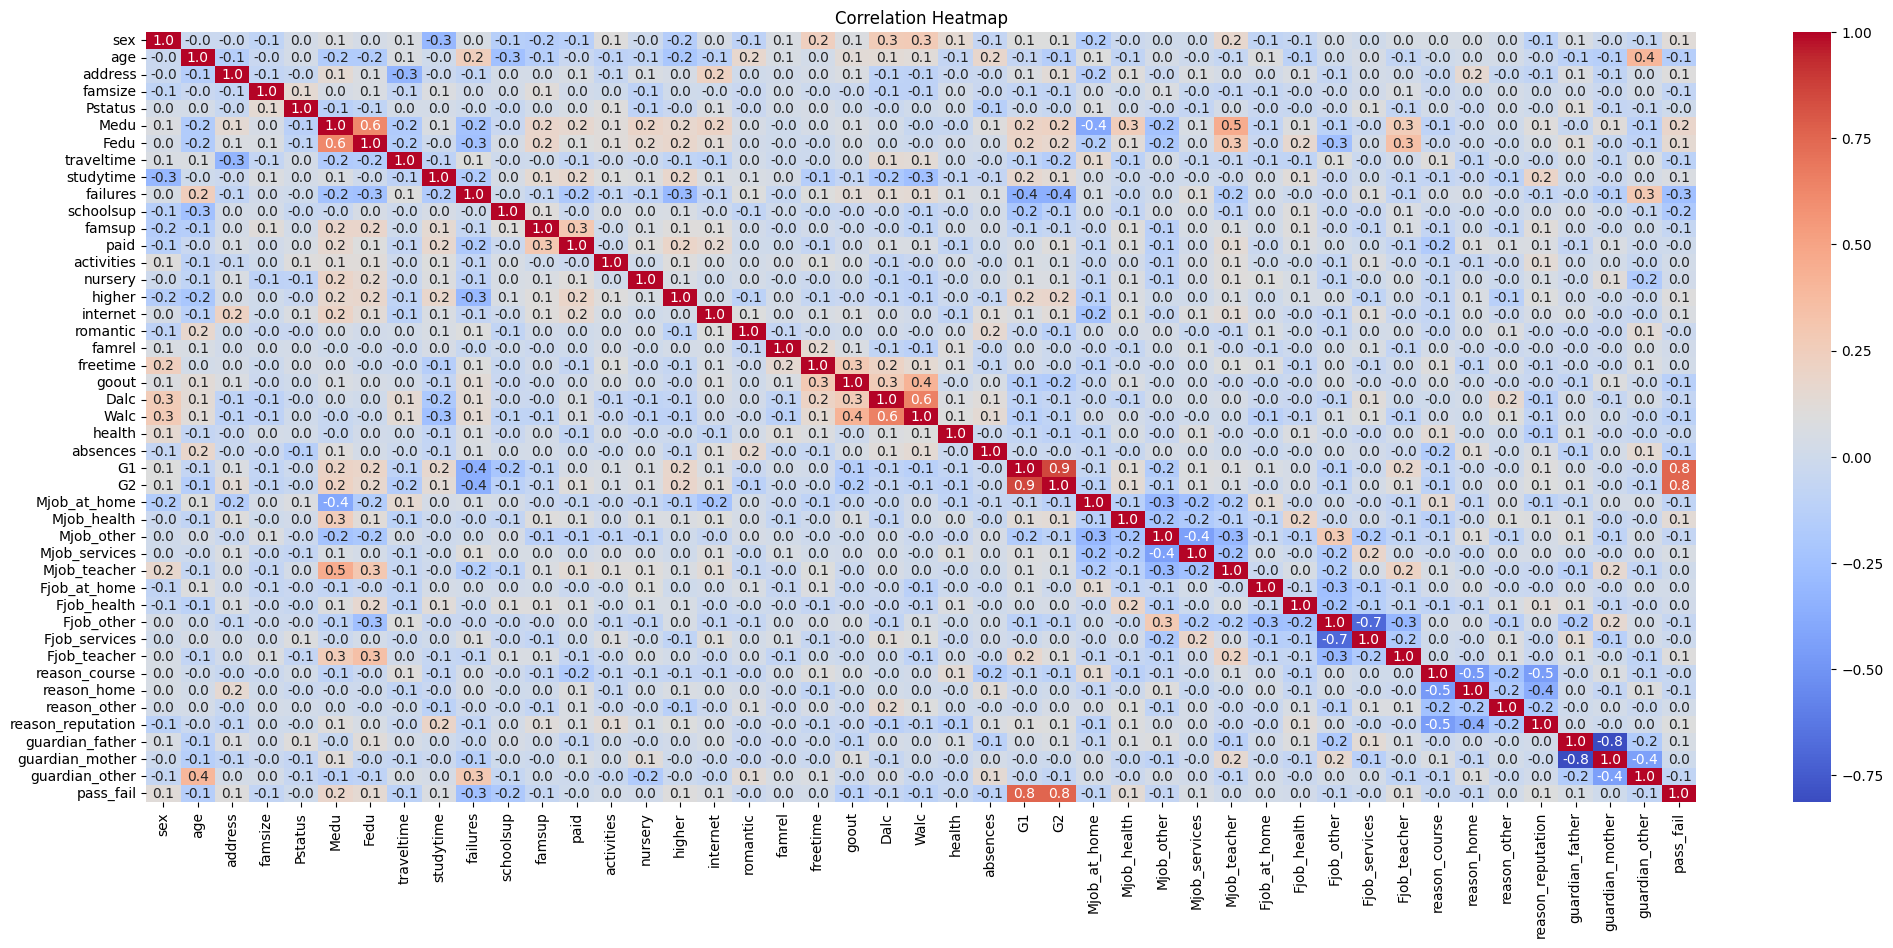

In [149]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(25, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".1f")
plt.title("Correlation Heatmap")
plt.show()

**Split to use use 'GP' for training and 'MS' for testing.**

In [150]:
# Separate data by school
df_GP = df[df['school'] == 'GP'].copy()
df_MS = df[df['school'] == 'MS'].copy()

# Define features (X) and target (y) for each school
X_train = df_GP.drop(['pass_fail', 'school'], axis=1)
y_train = df_GP['pass_fail']

X_test = df_MS.drop(['pass_fail', 'school'], axis=1)
y_test = df_MS['pass_fail']

print(f"Training data shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing data shape: X_test {X_test.shape}, y_test {y_test.shape}")

Training data shape: X_train (349, 44), y_train (349,)
Testing data shape: X_test (46, 44), y_test (46,)


**Scalling for KNN and Logistic Regression**

In [151]:
numeric_cols = ['age','absences','G1','G2','studytime','traveltime',
                'failures','famrel','freetime','goout','Dalc','Walc','health']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# **Training Models**


**Logistic Regression**

In [152]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')
log_reg.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg.predict(X_test)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)
report_log_reg = classification_report(y_test, y_pred_log_reg)

print(f"Logistic Regression Accuracy: {accuracy_log_reg:.4f}")
print("\nLogistic Regression Classification Report:")
print(report_log_reg)

Logistic Regression Accuracy: 0.9130

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        31
           1       0.82      0.93      0.88        15

    accuracy                           0.91        46
   macro avg       0.89      0.92      0.90        46
weighted avg       0.92      0.91      0.91        46



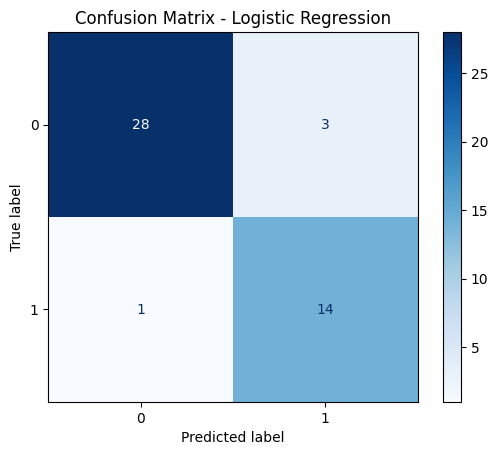

In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for Logistic Regression
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
disp_log_reg = ConfusionMatrixDisplay(confusion_matrix=cm_log_reg, display_labels=[0, 1])
disp_log_reg.plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Logistic Regression - feature Coefficients

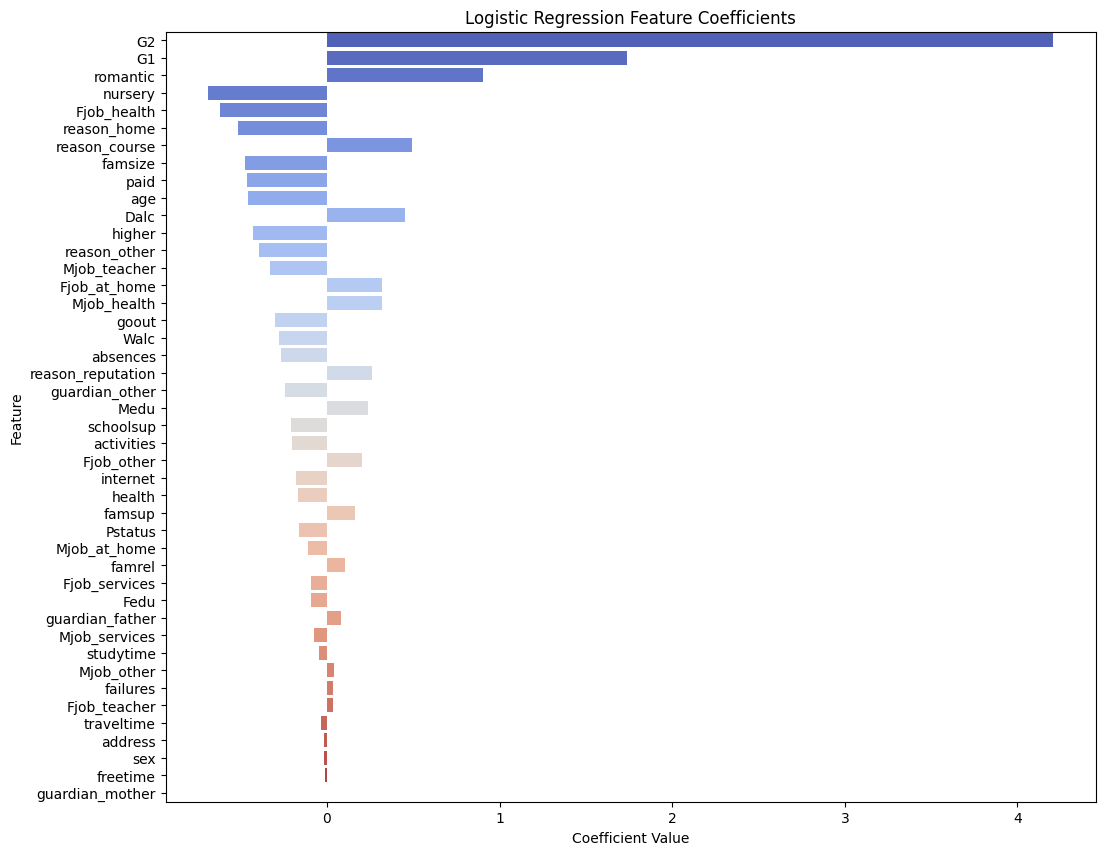

In [154]:
import pandas as pd

# Get coefficients from the Logistic Regression model
coefficients = log_reg.coef_[0]

# Create a Series for better visualization
feature_coefficients = pd.Series(coefficients, index=X_train.columns)

# Sort the coefficients by absolute value
sorted_coefficients = feature_coefficients.reindex(feature_coefficients.abs().sort_values(ascending=False).index)

# Plot the feature coefficients
plt.figure(figsize=(12, 10))
sns.barplot(x=sorted_coefficients.values, y=sorted_coefficients.index, hue=sorted_coefficients.index, palette='coolwarm', legend=False)
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.show()

**KNN (K- Nearest Neighbours)**

In [155]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize and train the KNN model
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn.predict(X_test)

# Evaluate the model
accuracy_knn = accuracy_score(y_test, y_pred_knn)
report_knn = classification_report(y_test, y_pred_knn)

print(f"KNN Accuracy: {accuracy_knn:.4f}")
print("\nKNN Classification Report:")
print(report_knn)

KNN Accuracy: 0.8696

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.87      0.90        31
           1       0.76      0.87      0.81        15

    accuracy                           0.87        46
   macro avg       0.85      0.87      0.86        46
weighted avg       0.88      0.87      0.87        46



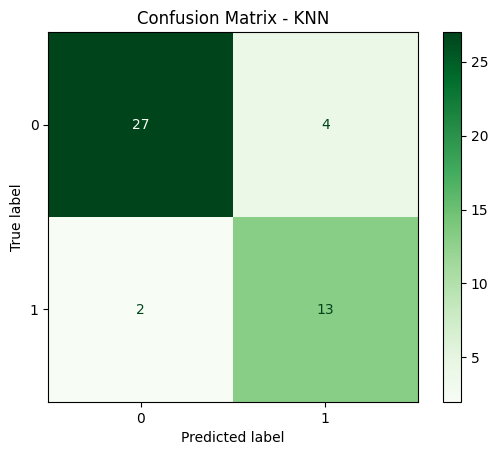

In [156]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=[0, 1])
disp_knn.plot(cmap='Greens')
plt.title('Confusion Matrix - KNN')
plt.show()

Finding optimal K

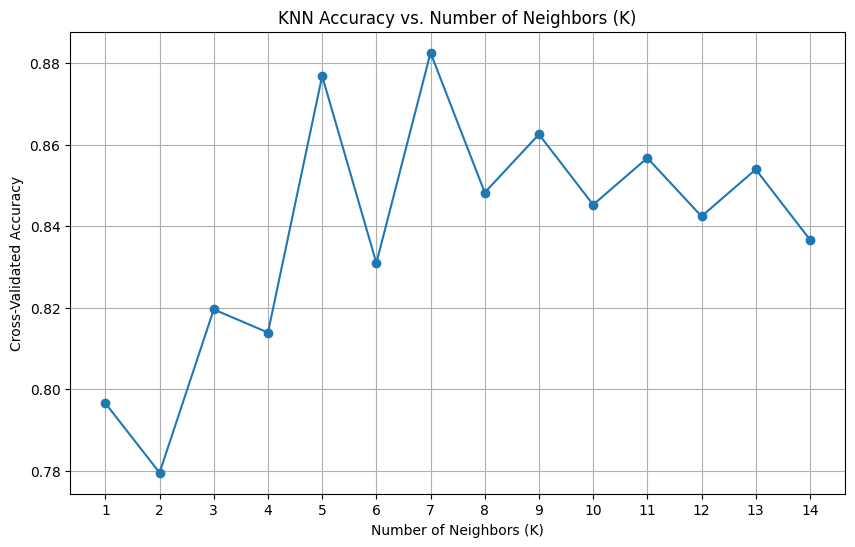

The optimal number of neighbors (K) is: 7


In [171]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# List to store cross-validation scores for different k values
k_scores = []

# Range of k values to test
k_range = range(1, 15) # Test k from 1 to 39

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    k_scores.append(scores.mean())

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(k_range, k_scores, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Accuracy vs. Number of Neighbors (K)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

# Find the optimal k
optimal_k_index = k_scores.index(max(k_scores))
optimal_k = k_range[optimal_k_index]
print(f"The optimal number of neighbors (K) is: {optimal_k}")

**Decision Tree**

In [157]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree model
decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree.predict(X_test)

# Evaluate the model
accuracy_dt = accuracy_score(y_test, y_pred_dt)
report_dt = classification_report(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("\nDecision Tree Classification Report:")
print(report_dt)

Decision Tree Accuracy: 0.8261

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        31
           1       0.73      0.73      0.73        15

    accuracy                           0.83        46
   macro avg       0.80      0.80      0.80        46
weighted avg       0.83      0.83      0.83        46



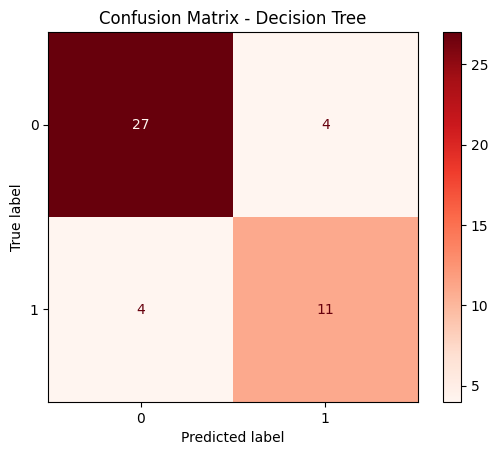

In [158]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=[0, 1])
disp_dt.plot(cmap='Reds')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Decision Tree Classifier Structure

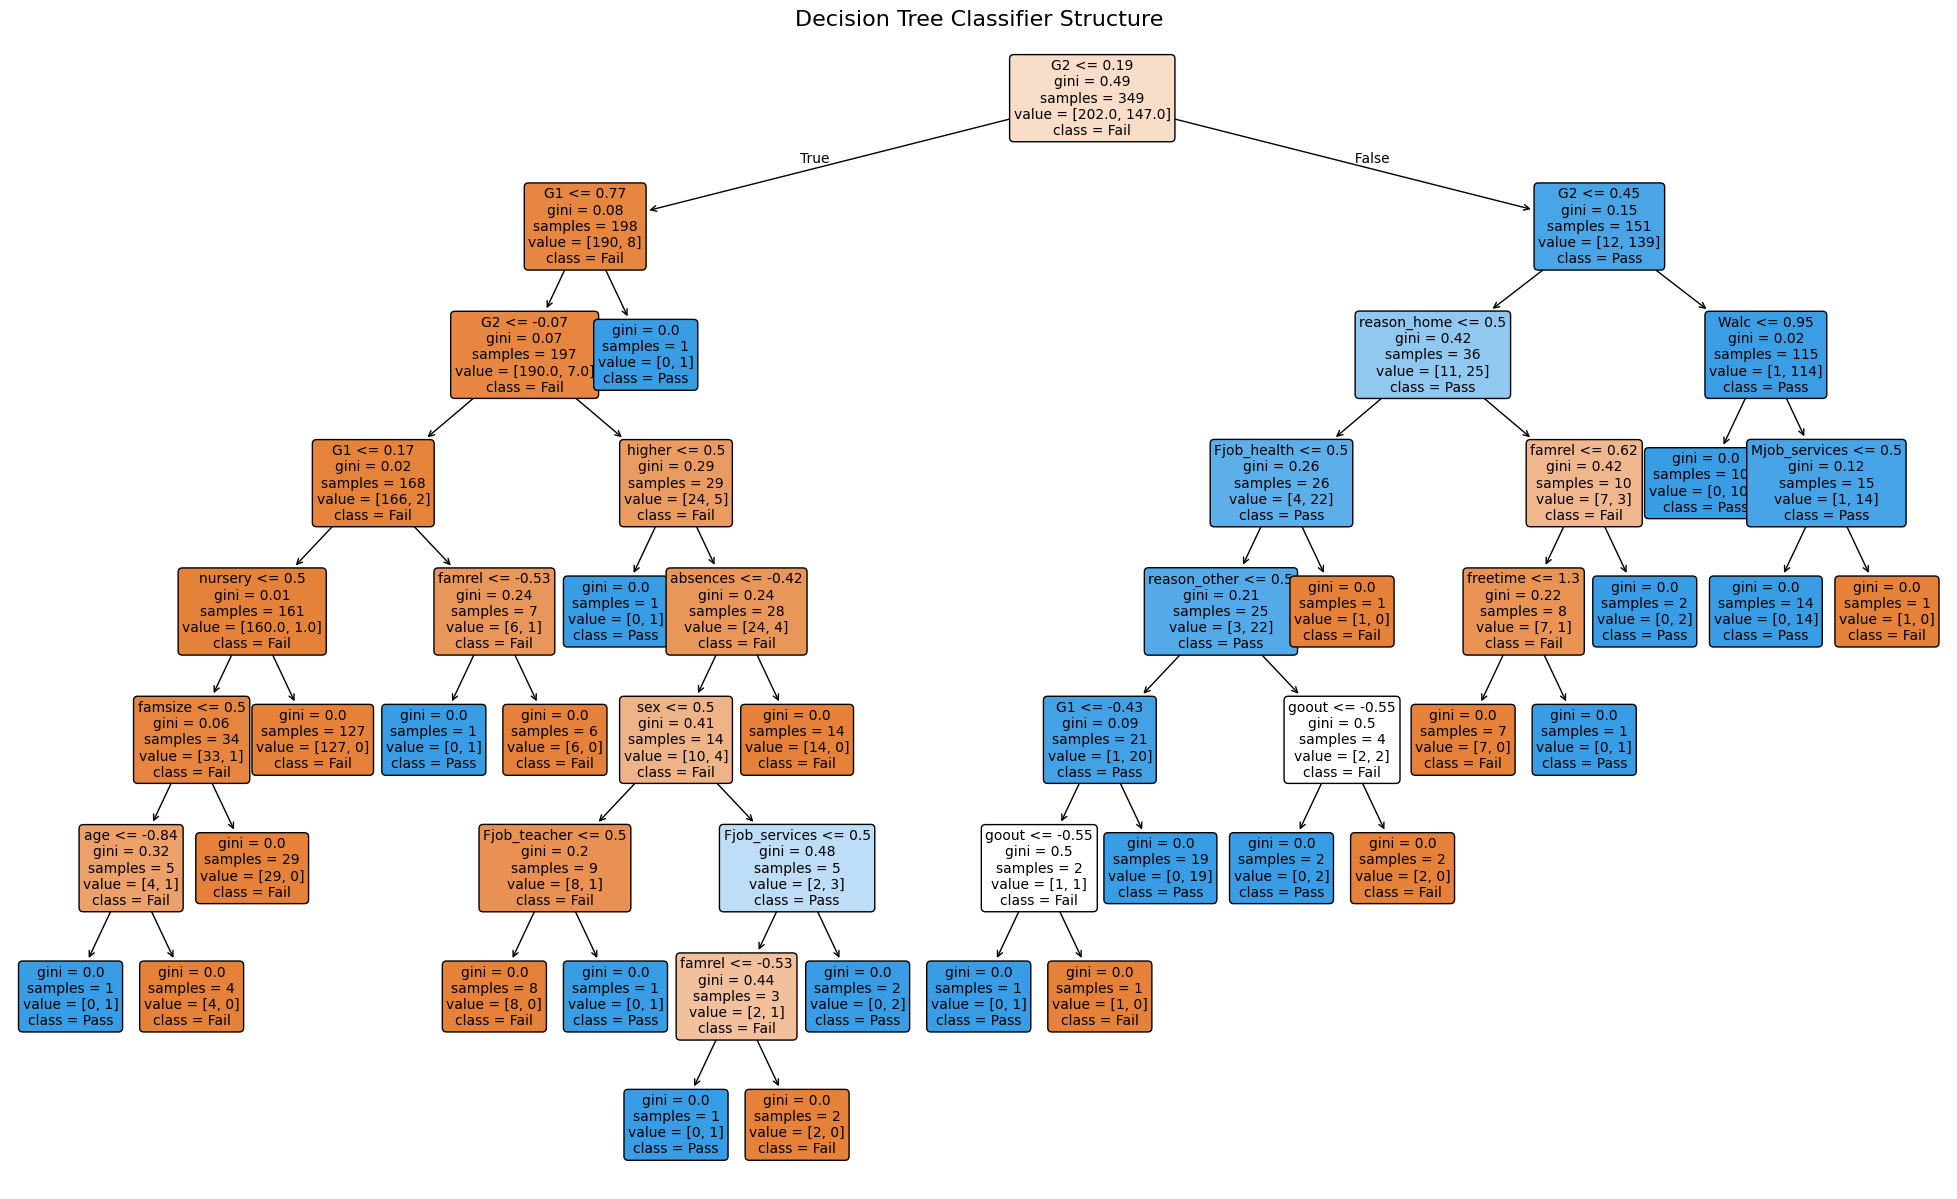

In [168]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))
plot_tree(decision_tree, filled=True, feature_names=X_train.columns.tolist(), class_names=['Fail', 'Pass'], rounded=True, precision=2, fontsize=10)
plt.title('Decision Tree Classifier Structure', fontsize=16)
plt.show()

**Random Forest**

In [160]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
random_forest = RandomForestClassifier(random_state=42)
# n_estimators=100
random_forest.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(report_rf)

Random Forest Accuracy: 0.9130

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        31
           1       0.82      0.93      0.88        15

    accuracy                           0.91        46
   macro avg       0.89      0.92      0.90        46
weighted avg       0.92      0.91      0.91        46



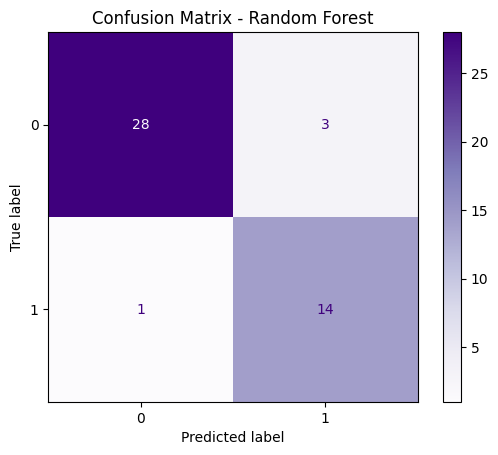

In [161]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
disp_rf.plot(cmap='Purples')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Random Forest - Extract Feature Importance

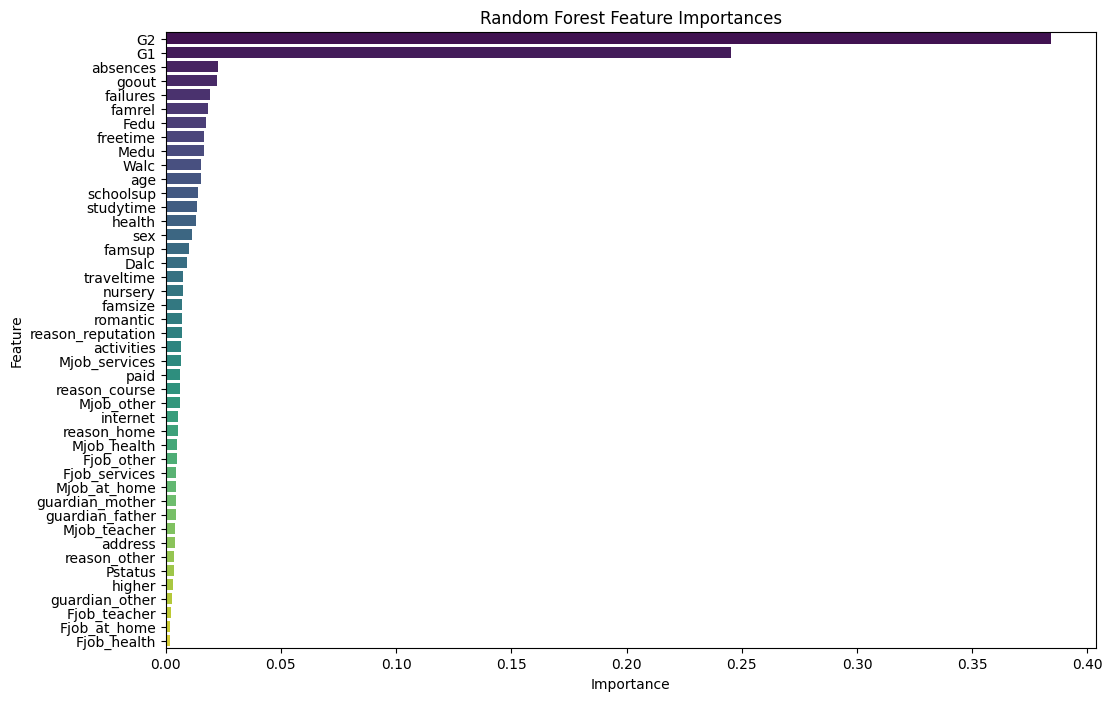

In [162]:
import pandas as pd

# Get feature importances from the Random Forest model
importances = random_forest.feature_importances_

# Create a Series for better visualization
feature_importances = pd.Series(importances, index=X_train.columns)

# Sort the importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.values, y=sorted_importances.index, hue=sorted_importances.index, palette='viridis', legend=False)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Cross validations**

In [163]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Logistic Regression K-fold Cross-Validation ---

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores for Logistic Regression
log_reg_scores = cross_val_score(log_reg, X_train, y_train, cv=kf, scoring='accuracy')

print("Logistic Regression Cross-Validation Scores (Accuracy):")
print(log_reg_scores)
print(f"Mean Accuracy: {log_reg_scores.mean():.4f}")
print(f"Standard Deviation: {log_reg_scores.std():.4f}")

Logistic Regression Cross-Validation Scores (Accuracy):
[0.9        0.87142857 0.87142857 0.91428571 0.92753623]
Mean Accuracy: 0.8969
Standard Deviation: 0.0226


In [164]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- KNN K-fold Cross-Validation ---

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores for KNN
knn_scores = cross_val_score(knn, X_train, y_train, cv=kf, scoring='accuracy')

print("\nKNN Cross-Validation Scores (Accuracy):")
print(knn_scores)
print(f"Mean Accuracy: {knn_scores.mean():.4f}")
print(f"Standard Deviation: {knn_scores.std():.4f}")


KNN Cross-Validation Scores (Accuracy):
[0.81428571 0.84285714 0.84285714 0.77142857 0.92753623]
Mean Accuracy: 0.8398
Standard Deviation: 0.0511


In [165]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Decision Tree K-fold Cross-Validation ---

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores for Decision Tree
dt_scores = cross_val_score(decision_tree, X_train, y_train, cv=kf, scoring='accuracy')

print("\nDecision Tree Cross-Validation Scores (Accuracy):")
print(dt_scores)
print(f"Mean Accuracy: {dt_scores.mean():.4f}")
print(f"Standard Deviation: {dt_scores.std():.4f}")


Decision Tree Cross-Validation Scores (Accuracy):
[0.91428571 0.94285714 0.94285714 0.92857143 0.88405797]
Mean Accuracy: 0.9225
Standard Deviation: 0.0220


In [166]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# --- Random Forest K-fold Cross-Validation ---

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Calculate cross-validation scores for Random Forest
rf_scores = cross_val_score(random_forest, X_train, y_train, cv=kf, scoring='accuracy')

print("\nRandom Forest Cross-Validation Scores (Accuracy):")
print(rf_scores)
print(f"Mean Accuracy: {rf_scores.mean():.4f}")
print(f"Standard Deviation: {rf_scores.std():.4f}")


Random Forest Cross-Validation Scores (Accuracy):
[0.91428571 0.92857143 0.97142857 0.97142857 0.91304348]
Mean Accuracy: 0.9398
Standard Deviation: 0.0264
